# GIK2FB Artificial Intelligence HT24

## Lab 3: Supervised Regression Learning, Naive Bayes

Dalarna University (c) Joonas Pääkkönen

### Deadline: Thursday December 19th, 2024 at 11:59 PM

Upload your .ipynb file to Canvas. No video, just the .ipynb file. Simply write your code in the .ipynb file and submit it. Do not zip anything, like the dataset, with it.

The aim of this lab is to familiarize yourself with Sklearn, so use Scikit-learn first and foremost as a source of information and Python methods, with the help of Pandas, NumPy, SciPy, Matplotlib and Seaborn, if needed.

In this lab, you do not need to split your data into training and testing. You can use all dataset for training your regression models.

Make sure that your code runs before submitting.

Keep the questions as they are, so simply add your answers either in code cells or Markdown cells after the questions.

More about Markdown:

https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html
https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet

Remember to fill in the information below, i.e., student name(s) and email address(es). Do not modify this header in any other way than by adding the student name(s) and email address(es) below.

### Student name(s):
Ali Adrian Nasrat
<br>
Anna Backolars

### DU email address(es): 
h22alian@du.se
<br>
h23annba@du.se

### Task 1: Getting used to scikit-learn.org

Task 1.1: Choose any regression metric from the sklearn.metrics module and explain in your own words what the metric measures and how. Also explain when you would, or would not, recommend using the regression metric that you chose.

### Vald metric: **mean_absolute_error (MAE)**

Måttet **Mean Absolute Error (MAE)** mäter den genomsnittliga absoluta skillnaden mellan faktiska och förutsagda värden, vilket visar hur långt ifrån modellen är i genomsnitt.  

**När man ska använda det**: När man vill ha ett lättförståeligt mått på prediktionsnoggrannhet i samma enhet som målet.  
**När man ska unvika att använda det**: När stora avvikelser behöver straffas hårdare, eftersom MAE behandlar alla fel lika.

Task 1.2: Explain the PolynomialFeatures method of the sklearn.preprocessing Python module. What is the PolynomialFeatures method? What can be done with it?

**PolynomialFeatures** är en metod i Scikit-learn som genererar nya funktioner genom att skapa alla polynomkombinationer av de ursprungliga funktionerna upp till en specificerad grad. Till exempel, om en indata är tvådimensionell i formen $[a, b]$, så blir polynomfunktionerna av grad 2: $[1, a, b, a², ab, b²]$. 

Denna metod används för att modellera icke-linjära relationer genom att omvandla linjära modeller till polynommodeller, vilket gör det möjligt att fånga mer komplexa samband i data. Det är användbart när man vill inkludera interaktionstermer eller när en linjär modell inte är tillräcklig för att beskriva data. 

Task 1.3: Keep the PolynomialFeatures method in mind, and consider a four-dimensional input sample of the form $(X_1,X_2,X_3,X_4)$. To what will these features be transformed if the *interaction_only* flag is set to True?

Om **interaction_only=True** för en fyrdimensionell indata $[a, b, c, d]$, skapas endast interaktionstermer. Resultatet blir: $[1,𝑎,𝑏,𝑐,𝑑,𝑎𝑏,𝑎𝑐,𝑎𝑑,𝑏𝑐,𝑏𝑑,𝑐𝑑]$

Task 1.4: Read the "Naive Bayes" page in the scikit-learn User Guide under Supervised learning, and answer the following question: What famous application of naive Bayes, other than the spam filtering application, does the page mention?

Förutom skräppostfiltrering nämner sidan att Naive Bayes-algoritmer används för ***textklassificering***.

Task 1.5: The same page explains what "naive" means in naive Bayes. Explain this in your own words.

**"Naive"** i Naive Bayes betyder att algoritmen antar att alla egenskaper är oberoende av varandra, vilket förenklar beräkningarna.

### Task 2: Linear regression

Task 2.1: Download the 'Scn2_GWP_NPV_pareto.csv' dataset from Canvas (the file is attached to the lab description on Canvas), and save the data into a variable called "paretodata" with the read.csv() method of the Pandas module. You need to import Pandas first.

In [358]:
import pandas as pd

file_path = r'data/Scn2_GWP_NPV_pareto.csv'
paretodata = pd.read_csv(file_path)

Task 2.2: Print the paretodata dataset by simply writing the variable name.

In [360]:
paretodata

,Unnamed: 0,PV Roof,PV Facade,GWP,NPV,Normalized GWP,Normalized NPV,GWP_1,GWP_2,GWP 1 per kWh(gCO2e/kWh),GWP 2 per kWh(gCO2e/kWh),Feasibility
0,0,114.000000,0.000000,297646.723768,92701.742394,1.000000,1.000000,301321.308824,297646.723768,24.315091,24.018571,False
1,1,0.509934,129.000000,279679.122005,-92723.761582,0.000000,0.000000,280256.648042,279679.122005,22.615280,22.568677,True
2,2,33.391952,129.000000,279717.067049,-68578.670472,0.002112,0.130215,282061.033968,279717.067049,22.760885,22.571739,True
3,3,114.000000,88.544501,285411.392284,11115.245124,0.319034,0.560004,294074.239754,285411.392284,23.730290,23.031242,True
4,4,114.000000,114.765623,281865.320973,-15891.179006,0.121675,0.414358,292721.576697,281865.320973,23.621137,22.745092,True
...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,12.319013,129.000000,279683.709946,-83585.366843,0.000255,0.049283,280769.223736,279683.709946,22.656643,22.569047,True
96,96,114.000000,26.029187,294020.680138,69848.376086,0.798190,0.876752,298882.241943,294020.680138,24.118271,23.725968,False
97,97,113.827461,34.291451,292869.554097,62355.297867,0.734123,0.836342,298126.113738,292869.554097,24.057255,23.633078,False
98,98,114.000000,11.570337,296033.257783,82622.268044,0.910201,0.945641,300215.416072,296033.257783,24.225851,23.888372,False


Task 2.3: How many observations does the dataset include?

In [362]:
num_observations = paretodata.shape[0]
print(f"Den innehåller: {num_observations} observationer.")

Den innehåller: 100 observationer.


Task 2.4: Use the Pandas describe() method to describe paretodata.

In [364]:
paretodata.describe()

,Unnamed: 0,PV Roof,PV Facade,GWP,NPV,Normalized GWP,Normalized NPV,GWP_1,GWP_2,GWP 1 per kWh(gCO2e/kWh),GWP 2 per kWh(gCO2e/kWh)
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,49.500000,98.904464,81.702970,286372.377742,9143.321445,0.372518,0.549369,293125.173251,286372.377742,23.653705,23.108789
std,29.011492,31.850905,42.706215,5867.529024,51324.380580,0.326562,0.276792,5805.135490,5867.529024,0.468445,0.473480
min,0.000000,0.509934,0.000000,279679.122005,-92723.761582,0.000000,0.000000,280256.648042,279679.122005,22.615280,22.568677
25%,24.750000,112.775911,42.664373,280716.297886,-26759.838766,0.057725,0.355744,292479.455939,280716.297886,23.601599,22.652372
50%,49.500000,113.989644,91.601450,284992.967125,8026.035377,0.295746,0.543344,293884.939831,284992.967125,23.715014,22.997477
75%,74.250000,114.000000,124.939552,291716.093972,54834.402451,0.669926,0.795781,297432.923049,291716.093972,24.001318,23.539999
max,99.000000,114.000000,129.000000,297646.723768,92701.742394,1.000000,1.000000,301321.308824,297646.723768,24.315091,24.018571


Task 2.5: What is the numerical value of the NPV feature under which 75% of the observations fall?

In [366]:
npv_75_percentile = paretodata['NPV'].quantile(0.75)
print(f"75:e percentilen för NPV är: {npv_75_percentile:.4f}")

75:e percentilen för NPV är: 54834.4025


Task 2.6: Explain in your own words what the describe() method shows you about the dataset.

Metoden **describe()** ger en sammanfattning av datasetet med statistik som medelvärde, standardavvikelse, min- och maxvärden samt percentiler för numeriska kolumner.

Task 2.7: In this lab we only use the NPV feature and the GWP feature. Save the NPV observations in a Pandas series called "x", and the GWP observations in a Pandas series called "y".

In [370]:
x = paretodata['NPV']
y = paretodata['GWP']
x.head(), y.head()

(0    92701.742394
 1   -92723.761582
 2   -68578.670472
 3    11115.245124
 4   -15891.179006
 Name: NPV, dtype: float64,
 0    297646.723768
 1    279679.122005
 2    279717.067049
 3    285411.392284
 4    281865.320973
 Name: GWP, dtype: float64)

Task 2.8: Plot the corresponding $(x,y)$ scatterplot.

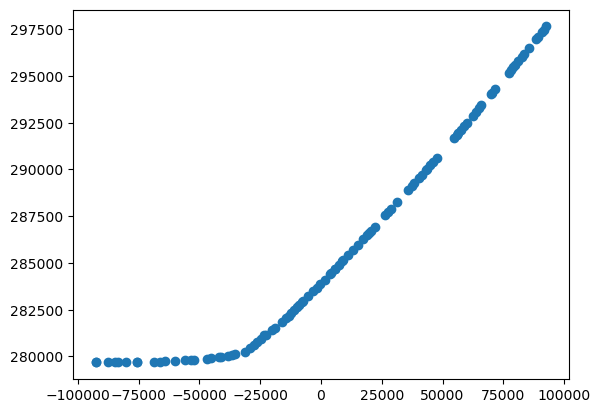

In [372]:
import matplotlib.pyplot as plt

plt.scatter(x, y)

Task 2.9: For the GWP against NPV dataset that you just (scatter)plotted, what is the range of interpolation?

In [374]:
npv_min = x.min()
npv_max = x.max()
print(f"Interpolationsintervallet är: ({npv_min:.4f}, {npv_max:.4f}).")

Interpolationsintervallet är: (-92723.7616, 92701.7424).


Task 2.10: The scatterplot shows that GWP is rather constant when NPV is lower than a certain threshold value. When NPV is above this threshold value, GWP seems to increase linearly with NPV. Choose a good value threshold for this NPV-threshold. Motivate your choice based on the dataset. It would be a good idea to write a little bit of code here.

In [376]:
threshold_suggestion = x[x > 0].median()
print(f"Tröskelvärdet valdes eftersom GWP är konstant vid låga NPV men ökar linjärt efteråt, baserat på medianen av positiva NPV-värden. Tröskelvärdet är: {threshold_suggestion:.4f}.")

Tröskelvärdet valdes eftersom GWP är konstant vid låga NPV men ökar linjärt efteråt, baserat på medianen av positiva NPV-värden. Tröskelvärdet är: 45581.1280.


Task 2.11: Fit a linear regression model to this (NPV,GWP) dataset: Use LinearRegression from sklearn.linear_model, and plot the regression line and the scatterplot in the same figure.

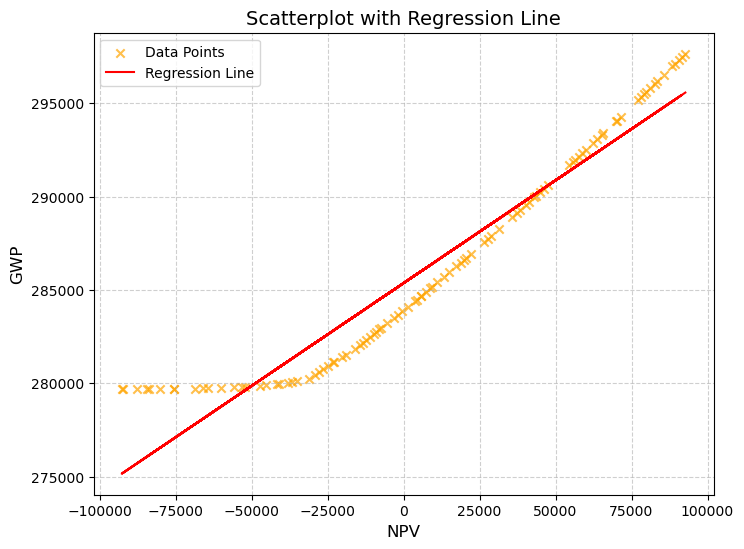

In [378]:
from sklearn.linear_model import LinearRegression
import numpy as np

x_reshaped = x.values.reshape(-1, 1)

model = LinearRegression()
model.fit(x_reshaped, y)

y_pred = model.predict(x_reshaped)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='orange', marker='x', alpha=0.7, label='Data Points')
plt.plot(x, y_pred, color='red', label='Regression Line')
plt.title("Scatterplot with Regression Line", fontsize=14)
plt.xlabel("NPV", fontsize=12)
plt.ylabel("GWP", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Task 2.12: Apply the "score" method (of sklearn.linear_model.LinearRegression) to the real values and the predicted values obtained by your model. What is the numerical value of this "score"? Explain in your own words what this "score" means.

In [380]:
score = model.score(x_reshaped, y)
print(f"Den numeriska poängen (R²-värdet) är {score:.4f}.")

print("R² visar hur väl modellen förklarar variationen i GWP, värdet 0.927 innebär att 92.7% av variationen förklaras, där 1 indikerar perfekt anpassning.")

Den numeriska poängen (R²-värdet) är 0.9265.
R² visar hur väl modellen förklarar variationen i GWP, värdet 0.927 innebär att 92.7% av variationen förklaras, där 1 indikerar perfekt anpassning.


Task 2.13: Looking at the scatterplot and the fitted linear regression line above (the plot produced by Task 2.11), one might argue that fitting a simple linear regression line would not be the best idea. Would you have a better idea? As a bonus, if you want, you can implement your idea here and build a better regression model.

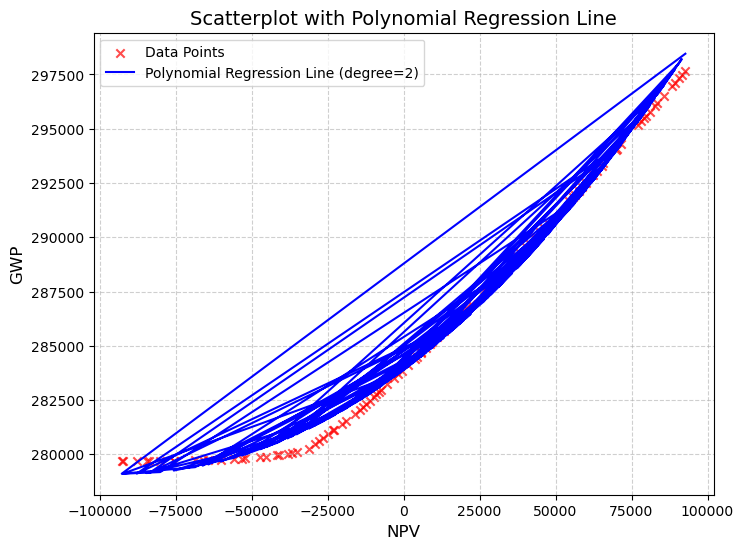

Polynomiell regression är en förlängning av linjär regression där vi använder polynomiella termer för att fånga upp icke-linjära mönster.


In [382]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x_reshaped)

poly_model = LinearRegression()
poly_model.fit(x_poly, y)

y_poly_pred = poly_model.predict(x_poly)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='red', marker='x', alpha=0.7, label='Data Points')
plt.plot(x, y_poly_pred, color='blue', label='Polynomial Regression Line (degree=2)')
plt.title("Scatterplot with Polynomial Regression Line", fontsize=14)
plt.xlabel("NPV", fontsize=12)
plt.ylabel("GWP", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Polynomiell regression är en förlängning av linjär regression där vi använder polynomiella termer för att fånga upp icke-linjära mönster.")

Task 2.14: Write a Python method that calculates the optimal values of the Ordinary Least Squares (OLS) parameter (weights) $w_1$ and $w_0$. You can use the formulas in the slides. Note: write two separate methods: one for $w_1$ and another one for $w_0$.

In [384]:
# Extract x and y from the dataset
x = paretodata['NPV']
y = paretodata['GWP']

# Reuse the calculate_w1 and calculate_w0 functions to compute OLS parameters
def calculate_w1(x, y):
    x_mean = x.mean()
    y_mean = y.mean()
    numerator = ((x - x_mean) * (y - y_mean)).sum()
    denominator = ((x - x_mean) ** 2).sum()
    return numerator / denominator

def calculate_w0(x, y, w1):
    y_mean = y.mean()
    x_mean = x.mean()
    return y_mean - w1 * x_mean

### Ordinary Least Squares (OLS) Parameters

The slope w_1 is calculated as:

$$
w_1 = \frac{\sum{(x - \bar{x})(y - \bar{y})}}{\sum{(x - \bar{x})^2}}
$$

The intercept w_0 is calculated as:

$$
w_0 = \bar{y} - w_1 \bar{x}
$$

Task 2.15: What are the values of the slope and the intercept given by the regression model that you built in Task 2.11? Note: there are built-in commands in Sklearn to extract these values for a regression model.

In [387]:
# Slope (w1) is stored in the .coef_ attribute
w1_builtin = model.coef_[0]

# Intercept (w0) is stored in the .intercept_ attribute
w0_builtin = model.intercept_

print(f"Sluttning (w1): {w1_builtin:.4f}")
print(f"Skärningspunkt (w0): {w0_builtin:.4f}")

Sluttning (w1): 0.1100
Skärningspunkt (w0): 285366.2251


### Results from Task 2.15

$$
w_1 = 0.1100 \quad \text{and} \quad w_0 = 285366.2251
$$


Task 2.16: What are the slope and intercept values for the (NPV,GWP) dataset given by the methods that you wrote yourself in Task 2.14?

In [391]:
print("Resultat från Uppgift 2.14\n")
# Calculate w1 and w0 for the provided dataset
w1 = calculate_w1(x, y)
w0 = calculate_w0(x, y, w1)

print(f"Lutning (w1): {w1:.4f}")
print(f"Skärningspunkt (w0): {w0:.4f}")

Resultat från Uppgift 2.14

Lutning (w1): 0.1100
Skärningspunkt (w0): 285366.2251


Task 2.17: Do the values you got in Task 2.15 coincide with those of Task 2.16?

Ja

### Beräkning av Lutning w_1 och Intercept w_0

För att beräkna lutningen och intercepten i en linjär regression används följande formler:

#### Lutning w_1:
$$
w_1 = \frac{\sum{(x_i - \bar{x})(y_i - \bar{y})}}{\sum{(x_i - \bar{x})^2}}
$$

Där:
 $$x_i$$ och $$y_i$$ är de individuella datapunkterna,
 $$\bar{x}$$ är medelvärdet av x,
 $$\bar{y}$$ är medelvärdet av y.

#### Intercept w_0:
$$
w_0 = \bar{y} - w_1 \cdot \bar{x}
$$

Där:
$$\bar{x}$$ och $$\bar{y}$$ är medelvärdena för x och y
w_1 är lutningen (beräknad ovan).

---

#### Exempel på beräkning:
Om vi har ett dataset $$x = [x_1, x_2, \dots, x_n]$$ och $$y = [y_1, y_2, \dots, y_n]$$ kan vi först beräkna medelvärdena:

$$
\bar{x} = \frac{\sum{x_i}}{n}, \quad \bar{y} = \frac{\sum{y_i}}{n}
$$

Sedan kan vi använda dessa formler för att beräkna w_1 och w_0.


### Task 3: Probability theory and Bayes' theorem

Task 3.1: Consider a statistical model with 3 parameters with a likelihood function $L(t)=-t^2 + 0.9t + 1$, where $t$ is a parameter that you are free to vary within the interval $0.4\leq t \leq 0.6$. Calculate the best possible Akaike information criterion (AIC) value of the model.

In [398]:
# Define the likelihood function
def likelihood(t):
    return -t**2 + 0.9 * t + 1

# Define the range for t
t_range = np.linspace(0.4, 0.6, 1000)  # Fine-grained range for better precision

# Find the t that maximizes the likelihood
t_max = t_range[np.argmax([likelihood(t) for t in t_range])]
L_max = likelihood(t_max)

# Number of parameters in the model
k = 3

# Calculate ln(L_max)
ln_L_max = np.log(L_max)

# Calculate AIC
AIC = 2 * k - 2 * ln_L_max

# Display results
print(f"Optimalt t: {t_max:.4f}")
print(f"Maximal sannolikhet (L_max): {L_max:.4f}")
print(f"Log-sannolikhet (ln(L_max)): {ln_L_max:.4f}")
print(f"Akaikes informationskriterium (AIC): {AIC:.4f}")

Optimalt t: 0.4501
Maximal sannolikhet (L_max): 1.2025
Log-sannolikhet (ln(L_max)): 0.1844
Akaikes informationskriterium (AIC): 5.6312


**Likelihood-funktionen:**

$$
L(t) = -t^2 + 0.9t + 1
$$

**Akaike Information Criterion (AIC):**

$$
\text{AIC} = 2k - 2\ln(\hat{L})
$$

där k = 3 (antal parametrar).

Task 3.2: Consider the figure below. Assume that each small grid square is of unit area (area 1). What is the total area of the whole grid?

In [402]:
# Dimensions of the grid
width = 20
height = 20

# Calculate the total area
total_area = width * height

# Print the result
print(f"Den totala ytan är: {total_area}")

Den totala ytan är: 400


### Total Area Calculation

The total area of the grid is calculated using the formula:

$$
\text{Total Area} = \text{Width} \times \text{Height}
$$

Given that the width is 20 and the height is 20, we have:

$$
\text{Total Area} = 20 \times 20 = 400
$$


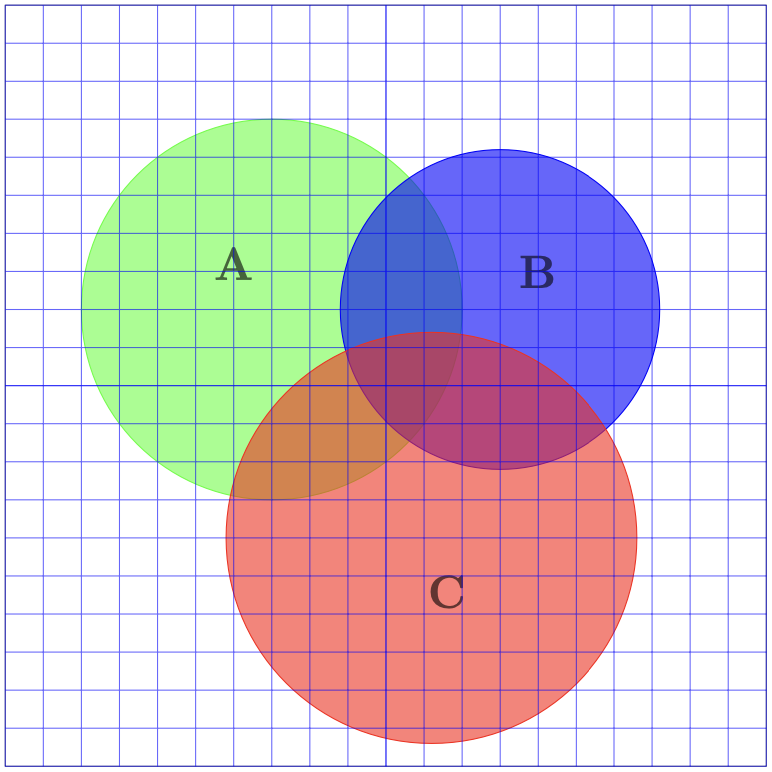

Task 3.3: Consider events A, B and C, the probabilities of which are represented by the areas of the green circle (A), the blue circle (B) and the red circle (C). The whole blue grid represents all possible events, that is, probability 1. The probability of A, $P(A)$, is hence the area of the green circle divided by the area of the whole grid. Based on the figure, estimate the numerical value of $P(A)$. Use any numerical methods and/or calculations that you want.

In [407]:
import math

# Total area av rutnätet
total_grid_area = 400  # 20x20

# Radien av den gröna cirkeln
radius = 5  # Ange radien här

# Beräkna arean av den gröna cirkeln
green_circle_area = math.pi * radius**2

# Beräkna sannolikheten P(A)
P_A = green_circle_area / total_grid_area

# Skriv ut resultatet
print(f"Sannolikheten P(A) är: {P_A:.4f}")

Sannolikheten P(A) är: 0.1963


### Estimation of P(A)

The probability of event A, represented by the green circle, is calculated as:

$$
P(A) = \frac{\text{Area of Green Circle}}{\text{Total Area of the Grid}}
$$


Task 3.4: Do the same for $P(B)$.

In [411]:
# Radien av den blåa cirkeln
radius = 4.25  # Ange radien här

# Beräkna arean av den blåa cirkeln
blue_circle_area = math.pi * radius**2

# Beräkna sannolikheten P(A)
P_B = blue_circle_area / total_grid_area

# Skriv ut resultatet
print(f"Sannolikheten P(B) är: {P_B:.4f}")

Sannolikheten P(B) är: 0.1419


### Estimation of P(B)

The probability of event B, represented by the blue circle, is calculated as:

$$
P(B) = \frac{\text{Area of Blue Circle}}{\text{Total Area of the Grid}}
$$

Task 3.5: Do the same for $P(C)$.

In [415]:
# Radien av den röda cirkeln
radius = 5.375  # Ange radien här

# Beräkna arean av den röda cirkeln
red_circle_area = math.pi * radius**2

# Beräkna sannolikheten P(A)
P_C = red_circle_area / total_grid_area

# Skriv ut resultatet
print(f"Sannolikheten P(C) är: {P_C:.4f}")

Sannolikheten P(C) är: 0.2269


### Estimation of P(C)

The probability of event C, represented by the red circle, is calculated as:

$$
P(C) = \frac{\text{Area of Red Circle}}{\text{Total Area of the Grid}}
$$

Task 3.6: Find $P(A|C)$. Use any numerical methods and/or calculations that you want.

In [419]:
# Given data
overlap_area = 15.5  # Area of overlap between A and C
total_grid_area = 400  # Total grid area
P_C = 0.2269  # Probability of C

# Calculate P(A ∩ C)
P_A_and_C = overlap_area / total_grid_area

# Calculate P(A|C)
P_A_given_C = P_A_and_C / P_C

# Print the results
print(f"P(A ∩ C) = {P_A_and_C:.4f}")
print(f"P(A|C) = {P_A_given_C:.4f}")

P(A ∩ C) = 0.0387
P(A|C) = 0.1708


### Beräkning av $$P(A|C)$$

För att beräkna $$P(A|C)$$ använder vi formeln för betingad sannolikhet:

$$
P(A|C) = \frac{P(A \cap C)}{P(C)}
$$

Där:
$$P(A \cap C)$$ är sannolikheten för att både A och C inträffar, och
P(C) är sannolikheten för C.

---

#### Steg 1: Beräkna $$P(A \cap C)$$
Sannolikheten för $$P(A \cap C)$$ beräknas genom:

$$
P(A \cap C) = \frac{\text{Overlap Area of \( A \) and \( C \)}}{\text{Total Grid Area}}
$$

Substituerar de givna värdena:
$$
P(A \cap C) = \frac{15.5}{400} = 0.0387
$$

---

#### Steg 2: Beräkna $$P(A|C)$$
Nu använder vi $$P(A \cap C)$$ och P(C) = 0.2269 för att beräkna P(A|C):

$$
P(A|C) = \frac{P(A \cap C)}{P(C)} = \frac{0.03875}{0.2269} \approx 0.1708
$$


Task 3.7: Find $P(B|C)$. Use any numerical methods and/or calculations that you want.

In [423]:
# Given data
overlap_area_BC = 17  # Overlapping squares between B and C
total_grid_area = 400  # Total grid area
P_C = 0.2269  # Probability of C

# Calculate P(B ∩ C)
P_B_and_C = overlap_area_BC / total_grid_area

# Calculate P(B|C)
P_B_given_C = P_B_and_C / P_C

# Print the results
print(f"P(B ∩ C) = {P_B_and_C:.4f}")
print(f"P(B|C) = {P_B_given_C:.4f}")

P(B ∩ C) = 0.0425
P(B|C) = 0.1873


### Beräkning av P(B|C)

För att beräkna P(B|C), använder vi formeln:

$$
P(B|C) = \frac{P(B \cap C)}{P(C)}
$$

---

#### Steg 1: Beräkna $$P(B \cap C)$$
Sannolikheten för $$P(B \cap C)$$ beräknas som:

$$
P(B \cap C) = \frac{\text{Overlap Area of \( B \) and \( C \)}}{\text{Total Grid Area}}
$$

Substituerar värden:
$$
P(B \cap C) = \frac{17}{400} = 0.0425
$$

---

#### Steg 2: Beräkna P(B|C)
Nu använder vi $$P(B \cap C) = 0.0425 $$ och $$P(C) = 0.2269$$

$$
P(B|C) = \frac{P(B \cap C)}{P(C)} = \frac{0.0425}{0.2269} \approx 0.1873
$$


Task 3.8: Use the Bayes' theorem to find $P(C|B)$. You may write fractions in these Markdown cells like this: $\frac{x+y}{y+x}$ (double-click this to see the source code).

In [427]:
# Given values
P_B_given_C = 0.0468  # P(B|C)
P_C = 0.2269          # P(C)
P_B = 56.7450 / 400   # P(B)

# Calculate P(C|B) using Bayes' theorem
P_C_given_B = (P_B_given_C * P_C) / P_B

# Print the result
print(f"P(C|B) = {P_C_given_B:.4f}")

P(C|B) = 0.0749


### Beräkning av P(C|B) med Bayes sats

Vi använder Bayes sats för att beräkna P(C|B):

$$
P(C|B) = \frac{P(B|C) P(C)}{P(B)}
$$

Där:
 $$P(B|C) \approx 0.1873$$
 $$P(C) = 0.2269$$
 $$P(B) = \frac{\text{Area of \( B \)}}{\text{Total Grid Area}} = \frac{56.7450}{400} \approx 0.1419$$

---

Substituerar in värdena:

$$
P(C|B) = \frac{0.0468 \times 0.2269}{0.1419} = \frac{0.01}{0.1419} \approx 0.0749
$$

---

Slutligt svar:

$$
P(C|B) \approx 0.0749
$$


Note: you do not need to find extremely precise with your answers, but your calculations must be accurate enough and well-motivated. If you carefully solve each of the tasks above, the chances of you passing this lab on the first try will be high.